In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split


### 1. train_test_split

In [15]:
df = pd.read_csv("../data/processed/diabetes_clean.csv")
df.shape

(101763, 30)

In [16]:
X = df.drop(columns=["readmitted", "patient_nbr"])
y = df["readmitted"]

In [17]:
print(X.shape)
print(y.shape)

(101763, 28)
(101763,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
print(X_train.shape)
print(X_test.shape)

(81410, 28)
(20353, 28)


In [20]:
num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(include="object").columns

print("Numeric:", list(num_cols))
print("Categorical:", list(cat_cols))

Numeric: ['age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'glyburide-metformin', 'total_diabetes_meds']
Categorical: ['race', 'gender', 'change', 'diabetesMed', 'diag_1_grp']


In [22]:
continuous_cols = [
    "age",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "total_diabetes_meds"
]

binary_cols = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "glimepiride",
    "glipizide",
    "glyburide",
    "pioglitazone",
    "rosiglitazone",
    "insulin",
    "glyburide-metformin"
]

cat_cols = [
    "race",
    "gender",
    "change",
    "diabetesMed",
    "diag_1_grp",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

### 2. feature encoding

In [25]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder(handle_unknown="ignore")

### 3. feature scaling

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

### 4.build baseline logistic regression

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cont", scaler, continuous_cols),
        ("bin", "passthrough", binary_cols),
        ("cat", cat_encoder, cat_cols)
    ]
)

In [33]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

In [34]:
lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cont', ...), ('bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
y_pred = lr_pipeline.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.6714489264481894
Precision: 0.18312284730195177
Recall: 0.5618670189343902
F1-score: 0.2762203701699318


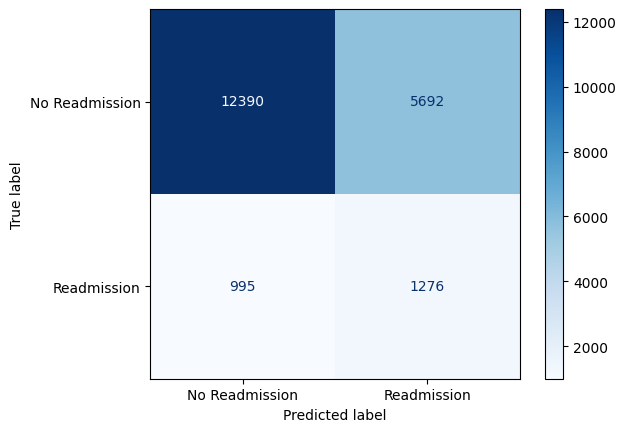

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    lr_pipeline,
    X_test,
    y_test,
    display_labels=["No Readmission", "Readmission"],
    cmap="Blues"
)

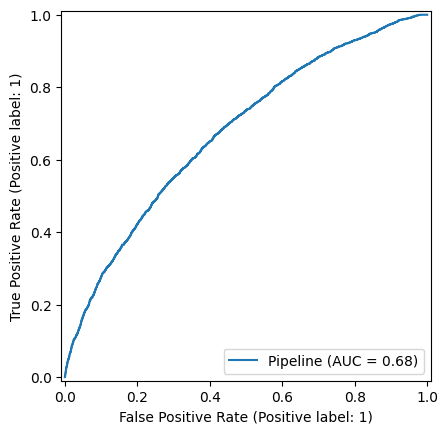

In [38]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(lr_pipeline, X_test, y_test)

### 5. implement semi-supervised learning


### 6. run experiments with different labeled ratios

### 7. compare results